* ¿Qué categoría de productos genera más ingresos?
* ¿El descuento aplicado afecta el monto promedio de compra?
* ¿Hay diferencias de gasto entre métodos de pago o ubicaciones?


# Sesión 1. Importamos la librería pandas


In [64]:
import pandas as pd

url = "https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto1_Analisis_Descriptivo/retail_store_sales.csv"
df = pd.read_csv(url)

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


# Sesión 2: Limpieza de nulos y duplicados




In [65]:
# VERIFICACIÓN DE DUPLICADOS
duplicados = df.duplicated().sum()
print("Cantidad de filas duplicadas:", duplicados)

ids_repetidos = df.duplicated(subset=["Transaction ID"]).sum()
print("Transaction ID repetidos:", ids_repetidos)

Cantidad de filas duplicadas: 0
Transaction ID repetidos: 0


Se verificó la existencia de filas duplicadas exactas mediante .duplicated().sum(), resultando en 0 casos. No se requiere tratamiento de duplicados en este dataset.

**FILAS CON CON DATOS FALTANTES**: Item - Price Per Unit - Quantity - Total Spent - Discount Applied



In [66]:
# TRATAMIENTO DE LOS NULOS
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentaje_nulos)

Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Item                 9.646123
Price Per Unit       4.842942
Quantity             4.803181
Total Spent          4.803181
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
Discount Applied    33.391650
dtype: float64


In [67]:
# .unique() muestra cada valor distinto que aparece en la columna, sin repetir
distinto = df["Discount Applied"].unique()
print(distinto)

[True False nan]


In [68]:
# Rellenamos los NaN con un texto que indique claramente que no sabemos
df["Discount Applied"] = df["Discount Applied"].fillna("Desconocido")
print(df["Discount Applied"].unique())

[True False 'Desconocido']


In [69]:
#VEMOS CUAL DE ESTAS FILAS LE FALTA UN VALOR PARA PODER RECUPERAR ALGUBNSO VALORES
falta_precio = df["Price Per Unit"].isnull()
falta_cantidad = df["Quantity"].isnull()
falta_total = df["Total Spent"].isnull()

print("Filas sin Price Per Unit:", falta_precio.sum())
print("Filas sin Quantity:", falta_cantidad.sum())
print("Filas sin Total Spent:", falta_total.sum())

Filas sin Price Per Unit: 609
Filas sin Quantity: 604
Filas sin Total Spent: 604


In [70]:
faltan_precio_y_cantidad = falta_precio & falta_cantidad
print("Filas sin Precio Y sin Cantidad a la vez:", faltan_precio_y_cantidad.sum())
faltan_precio_y_total = falta_precio & falta_total
print("Filas sin Precio Y sin Total a la vez:", faltan_precio_y_total.sum())
faltan_cantidad_y_total = falta_cantidad & falta_total
print("Filas sin Cantidad Y sin Total a la vez:", faltan_cantidad_y_total.sum())

Filas sin Precio Y sin Cantidad a la vez: 0
Filas sin Precio Y sin Total a la vez: 0
Filas sin Cantidad Y sin Total a la vez: 604


In [71]:
filas_sin_precio = df["Price Per Unit"].isnull()
df.loc[filas_sin_precio, "Price Per Unit"] = df.loc[filas_sin_precio, "Total Spent"] / df.loc[filas_sin_precio, "Quantity"]
print("Nulos restantes en Price Per Unit:", df["Price Per Unit"].isnull().sum())


Nulos restantes en Price Per Unit: 0


In [72]:
print("Filas actuales:", len(df))

Filas actuales: 12575


In [73]:
# Identificamos las filas que tienen Quantity Total Spent
filas_completas = df["Quantity"].notnull() | df["Total Spent"].notnull()
df = df[filas_completas]
print("Filas totales después de eliminar:", len(df))

Filas totales después de eliminar: 11971


In [74]:
falta_item = df["Item"].isnull()
print(df.loc[falta_item, "Category"].value_counts())

Category
Milk Products                         88
Food                                  81
Computers and electric accessories    80
Electric household essentials         79
Butchers                              75
Patisserie                            72
Beverages                             69
Furniture                             65
Name: count, dtype: int64


In [75]:
# Eliminamos las filas donde falta el nombre del producto (Item)
df = df[df["Item"].notnull()]
print("Filas totales después de eliminar los nulos de Item:", len(df))


Filas totales después de eliminar los nulos de Item: 11362


# Sesión 3: Tendencia central y dispersión por categoría


In [76]:
promedio_por_categoria = df.groupby("Category")["Total Spent"].mean()
print(promedio_por_categoria)

Category
Beverages                             131.729853
Butchers                              138.934553
Computers and electric accessories    129.493558
Electric household essentials         133.918928
Food                                  129.484572
Furniture                             127.758219
Milk Products                         119.822807
Patisserie                            125.880570
Name: Total Spent, dtype: float64


In [77]:
median_por_categoria = df.groupby("Category")["Total Spent"].median()
print(median_por_categoria)

Category
Beverages                             109.5
Butchers                              120.0
Computers and electric accessories    111.0
Electric household essentials         110.0
Food                                  110.5
Furniture                             100.0
Milk Products                          92.5
Patisserie                            102.0
Name: Total Spent, dtype: float64


In [78]:
desviacion_por_categoria = df.groupby("Category")["Total Spent"].std()
print(desviacion_por_categoria)

Category
Beverages                              98.442387
Butchers                              100.445360
Computers and electric accessories     88.351171
Electric household essentials          95.212039
Food                                   91.140499
Furniture                              98.160781
Milk Products                          92.798284
Patisserie                             90.762902
Name: Total Spent, dtype: float64


Análisis de tendencia central y dispersión por categoría
Se calculó la media, mediana y desviación estándar de Total Spent agrupadas por Category. En las 8 categorías, la media se ubica sistemáticamente por encima de la mediana (diferencias de 18-28 puntos), y la desviación estándar representa entre el 68% y 77% de la media. Esto sugiere una dispersión considerable en los montos de compra, con posible presencia de valores atípicos que serán investigados formalmente con el método IQR en la Sesión 5.

# Sesión 4: Visualizaciones

Text(0, 0.5, 'Cantidad de transacciones')

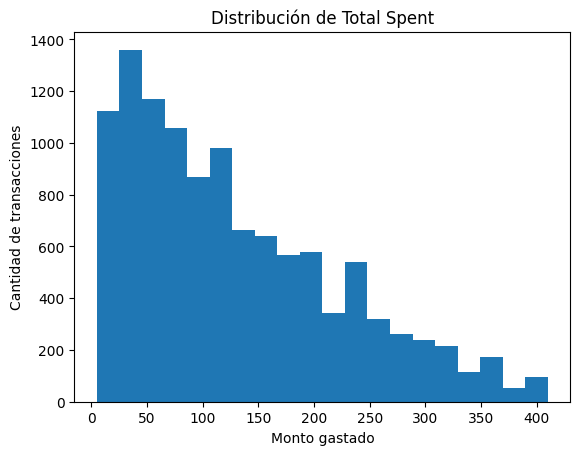

In [79]:
import matplotlib.pyplot as plt

plt.hist(df["Total Spent"], bins=20)
plt.title("Distribución de Total Spent")
plt.xlabel("Monto gastado")
plt.ylabel("Cantidad de transacciones")


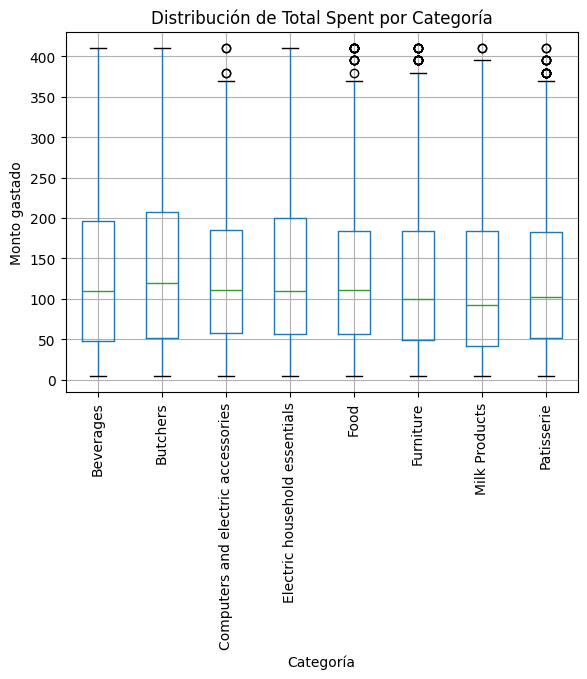

In [80]:
df.boxplot(column="Total Spent", by="Category")

plt.title("Distribución de Total Spent por Categoría")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Monto gastado")

plt.xticks(rotation=90)

plt.show()

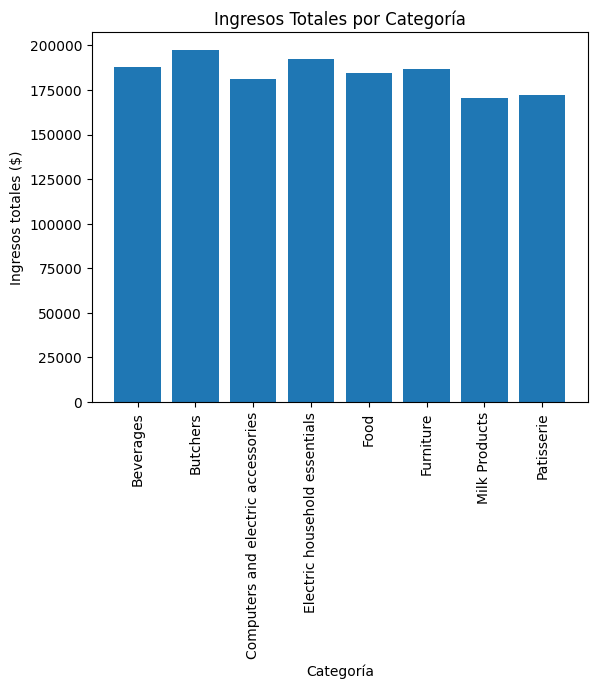

In [81]:
ventas_totales_por_categoria = df.groupby("Category")["Total Spent"].sum()
plt.bar(ventas_totales_por_categoria.index, ventas_totales_por_categoria.values)

plt.title("Ingresos Totales por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos totales ($)")

plt.xticks(rotation=90)
plt.show()

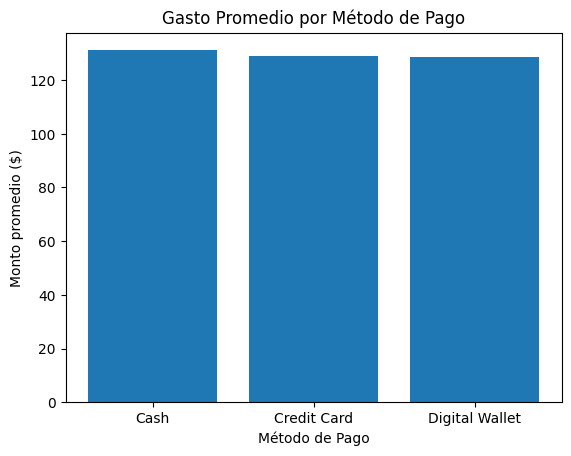

Payment Method
Cash              131.140158
Credit Card       129.025208
Digital Wallet    128.683396
Name: Total Spent, dtype: float64


In [82]:
promedio_por_pago = df.groupby("Payment Method")["Total Spent"].mean()

plt.bar(promedio_por_pago.index, promedio_por_pago.values)
plt.title("Gasto Promedio por Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Monto promedio ($)")

plt.show()
print(promedio_por_pago)

# Sesión 5: Outliers con el método IQR


In [83]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["Total Spent"] < limite_inferior) | (df["Total Spent"] > limite_superior)]

print("Cantidad de outliers en Total Spent:", len(outliers))
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Cantidad de outliers en Total Spent: 56
Límite inferior: -158.0
Límite superior: 402.0


In [84]:
#Para no eliminar los valores atípicos crearemos dos data frame nuevos sin afectar el que ya se ahtrabajado. Uno será para quel que contienuelos valores atípicos y el otro no.

df_outliers = df[df["Total Spent"] > limite_superior]

df_normal = df[df["Total Spent"] <= limite_superior]

# Verificamos que los dos grupos sumen el total original
print("Filas en df_normal:", len(df_normal))
print("Filas en df_outliers:", len(df_outliers))
print("Suma de ambos:", len(df_normal) + len(df_outliers))
print("Total original:", len(df))

Filas en df_normal: 11306
Filas en df_outliers: 56
Suma de ambos: 11362
Total original: 11362


# Sesión 6: Conclusiones de negocio


Conclusión 1 — Segmento de clientes de alto gasto

Hallazgo: Se identificó un segmento de 56 transacciones (0.49% del total) que superan los $402, el umbral de outlier calculado mediante el método IQR. Este segmento se concentra principalmente en las categorías Food, Beverages y Butchers (11 transacciones cada una, el 59% de todos los outliers).

Implicancia de negocio: Este grupo representa compras excepcionalmente grandes que podrían corresponder a clientes de alto valor, compras al por mayor, o eventos puntuales (celebraciones, abastecimiento). Se recomienda investigar este segmento en mayor profundidad (¿son clientes recurrentes o compras únicas?) para evaluar estrategias de fidelización, promociones dirigidas, o programas de puntos que incentiven la repetición de este comportamiento de compra.

Conclusión 2 — Milk Products como categoría de bajo desempeño

Hallazgo: Milk Products presenta el menor ingreso total ($170.748) y el menor ticket promedio ($119.82) entre las 8 categorías analizadas, además de una de las menores cantidades de outliers (solo 2), lo que sugiere un comportamiento de compra consistentemente bajo, sin picos que compensen el promedio.

Implicancia de negocio: Esta categoría podría beneficiarse de una revisión estratégica: evaluar si el precio actual es competitivo, si falta variedad de productos dentro de la categoría, o si conviene una campaña promocional específica para incentivar tickets de compra más altos.